# Credit Card Fraud Detection - Exploratory Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Credit Card Fraud Detection dataset to better understand transaction patterns and identify the distribution of fraudulent and legitimate transactions.

### Dataset Information

- **Dataset:** Credit Card Fraud Detection
- **Source:** Kaggle - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- **Provider:** Machine Learning Group – Université Libre de Bruxelles (ULB)
- **Transactions:** 284,807
- **Fraudulent Transactions:** 492
- **Features:** 31 (V1–V28, Time, Amount, Class)

### Objective

The objective of this project is to explore the dataset, examine its structure, analyze transaction amounts, visualize fraud distribution, and understand relationships between numerical features using Python.



## Dataset Overview

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("creditcard.csv")

print("Rows and Columns:", df.shape)

Rows and Columns: (1986, 31)



The dataset contains 284,807 rows and 31 columns.

## Dataset Structure

In [7]:
print(df.columns)
df.info()

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1986 entries, 0 to 1985
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1986 non-null   int64  
 1   V1      1986 non-null   float64
 2   V2      1986 non-null   float64
 3   V3      1986 non-null   float64
 4   V4      1986 non-null   float64
 5   V5      1986 non-null   float64
 6   V6      1986 non-null   float64
 7   V7      1986 non-null   float64
 8   V8      1986 non-null   float64
 9   V9      1986 non-null   float64
 10  V10     1986 non-null   float64
 11  V11     1986 non-null   float64
 12  V12     1986 non-null   float64
 13  V13     1986 non-null   float64
 14  V14     1985 non-null   float64


All features except Class and Amount are anonymized.

## Missing Value Analysis

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64



The dataset contains no missing or null values.

## Class Distribution

In [9]:
fraud = df["Class"].value_counts()

print(f"Legitimate Transactions: {fraud[0]}")
print(f"Fraudulent Transactions: {fraud[1]}")

Legitimate Transactions: 1983
Fraudulent Transactions: 2



The dataset is highly imbalanced, with legitimate transactions greatly outnumbering fraudulent transactions.

## Fraud Percentage Analysis

In [10]:
fraud_percentage = (df["Class"].sum() / len(df)) * 100

print(f"Fraudulent Transactions: {fraud_percentage:.4f}%")

Fraudulent Transactions: 0.1007%



Fraudulent transactions account for only a very small percentage of the total transactions.

## Transaction Amount Statistics

In [11]:
print("Minimum Amount:", df["Amount"].min())
print("Maximum Amount:", df["Amount"].max())
print("Mean Amount:", df["Amount"].mean())
print("Median Amount:", df["Amount"].median())

Minimum Amount: 0.0
Maximum Amount: 7712.43
Mean Amount: 68.60246851385392
Median Amount: 15.09



The transaction amounts vary significantly, with a wide range between the minimum and maximum values.

## Maximum Transaction Analysis

In [12]:
max_transaction = df.loc[df["Amount"].idxmax()]
print("Maximum Amount:", max_transaction["Amount"])
print("Fraudulent:", "Yes" if max_transaction["Class"] == 1 else "No")

Maximum Amount: 7712.43
Fraudulent: No



The maximum transaction amount was identified, and its class indicates whether it is legitimate or fraudulent.

## Bar Chart Visualization

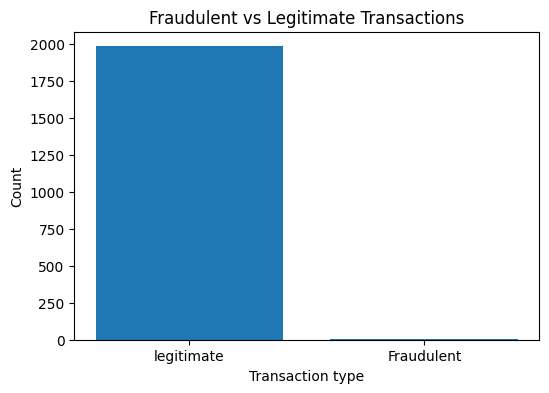

In [13]:
counts = df["Class"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["legitimate", "Fraudulent"], counts)
plt.title("Fraudulent vs Legitimate Transactions")
plt.xlabel("Transaction type")
plt.ylabel("Count")
plt.show()


The bar chart clearly shows the imbalance between legitimate and fraudulent transactions.

## Transaction Amount Distribution

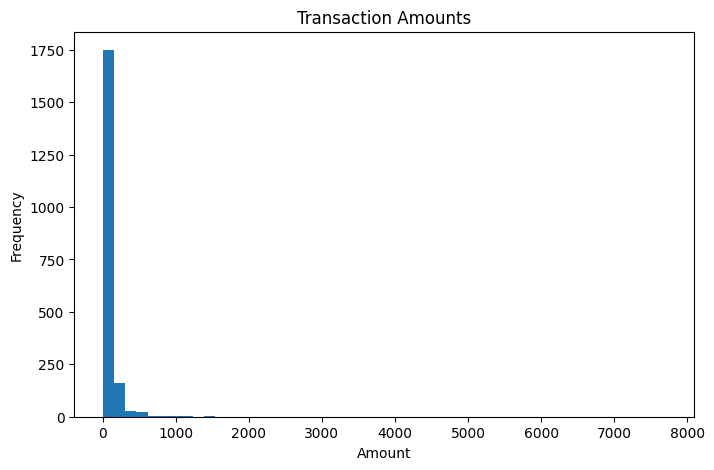

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


Most transaction amounts are relatively small, while only a few transactions have very high amounts.

## Correlation Analysis

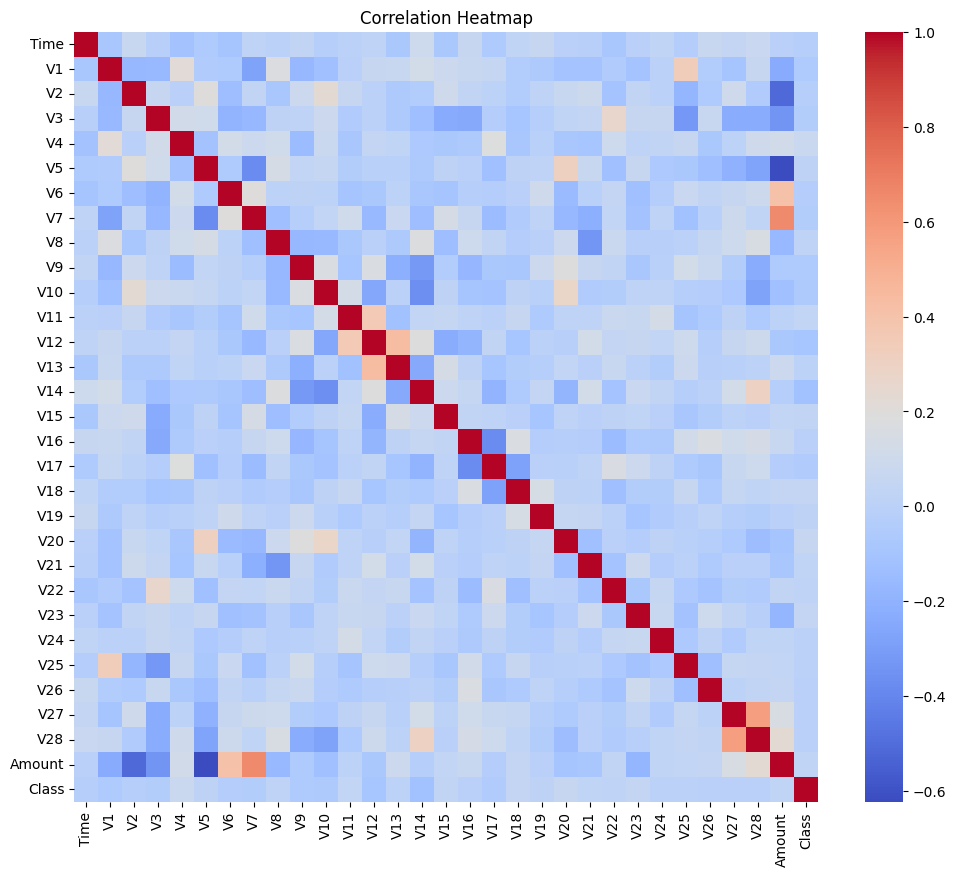

In [15]:
plt.figure(figsize=(12,10))
correlation = df.corr()
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


The heatmap helps visualize the relationships between numerical features. Most features have weak correlations with each other.

## Transaction Amount Distribution (Boxplot)

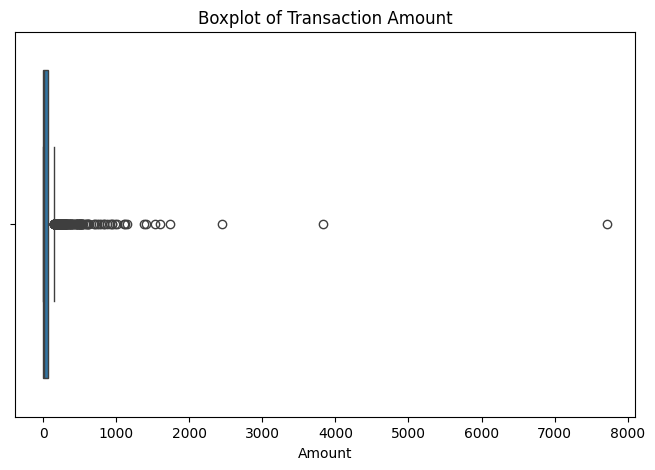

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Amount")

plt.show()

## Fraud vs Legitimate Transactions

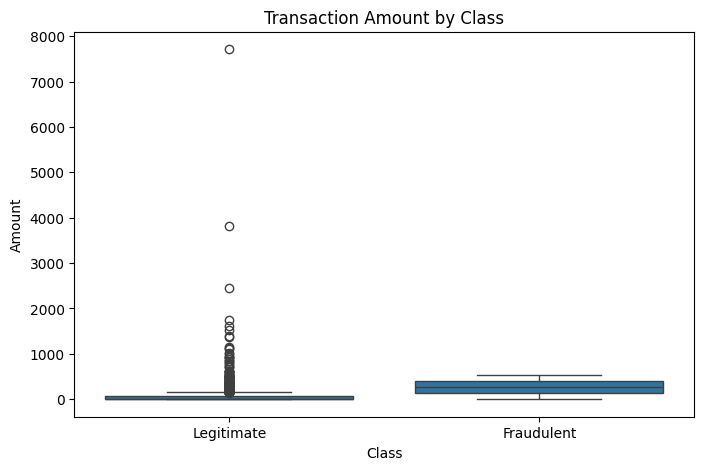

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.xticks([0,1], ["Legitimate", "Fraudulent"])

plt.title("Transaction Amount by Class")

plt.show()

The boxplot compares transaction amounts between legitimate and fraudulent transactions, helping identify differences in their distributions.

## Transaction Time Distribution

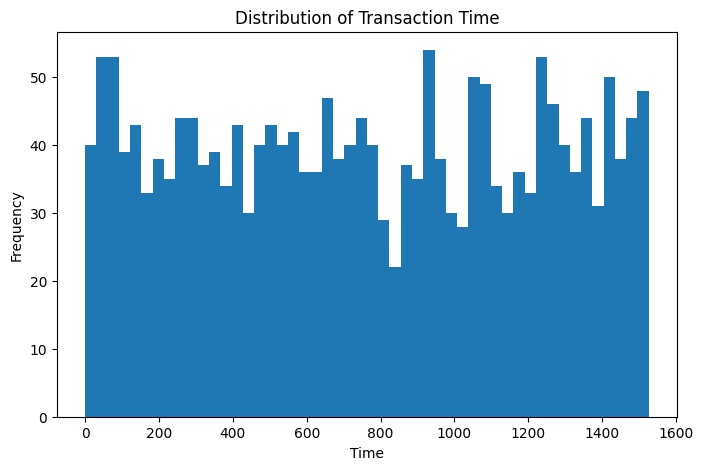

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

The histogram shows how transactions are distributed over time, helping identify periods with higher transaction activity.

# Conclusion

The exploratory data analysis shows that the dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of the total data. Statistical analysis and visualizations provide valuable insights into transaction patterns and feature relationships, forming a solid foundation for building fraud detection models.